In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
sys.path.insert(0, '..')
from lstm import AVERT_LSTM
import itertools
import tensorflow as tf
import keras
import pickle
import os
from orenstein_analysis.measurement import helper
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

processed_dpath = '../processed_data/'

# colors
import cmcrameri.cm as cmc
import colorcet as cc
import farrow_and_ball as fab
from matplotlib.colors import LinearSegmentedColormap, rgb2hex
cmap_temp = cmc.vik
cmap = cmc.lipari
cmap_cyclic = cmap_cyclic = cc.cm["cyclic_isoluminant"]#cmc.romaO
temp_palette_gen, blank = helper.colormap_generator(0,1,cmap=cmap_temp, cmap_frac=0.1)
cmap_palette_gen, blank = helper.colormap_generator(0,1,cmap=cmap, cmap_frac=0.1)
palette_temp = [helper.adjust_color_hls(temp_palette_gen(i),'l',1) for i in np.linspace(0,1,16)]
palette_cmap = [helper.adjust_color_hls(cmap_palette_gen(i),'l',1) for i in np.linspace(0,1,16)]
palette_temp_light = [helper.adjust_color_hls(temp_palette_gen(i),'l',1.5) for i in np.linspace(0,1,16)]
mm = 1/25.4 # unit conversion for figures
dpi = 1200

# FAB based palette
if 1==1:
    fabmap_dark = fab.SpectralPalette.DEEPSPEC
    fabmap = fab.SpectralPalette.SPEC
    fabmap_light = fab.SpectralPalette.LIGHTSPEC
    palette_dark = fab.get_interpolated_palette(fabmap_dark, 16)
    palette = fab.get_interpolated_palette(fabmap, 16)
    palette_light = fab.get_interpolated_palette(fabmap_light, 16)


style_sheet_tex = '/Users/oxide/Documents/research/orenstein/code/figures_style_sheet_tex.mplstyle' # for making really final figures
#matplotlib.style.use(style_sheet_tex)
#plt.rcParams.update({"font.family": "Avenir"})

plt.rcParams.update(
    {
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "pdf.fonttype": 42,
        "font.family": "Avenir",
        "font.size": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 5,
        "ytick.major.size": 5,
        "xtick.major.pad": 6.5,
        "ytick.major.pad": 6.5,
    }
)

In [2]:
# load data

df = pd.read_csv(processed_dpath+f'dataInterpolated.csv', index_col=0)
df.index = pd.to_datetime(df.index)

eps = 1e-6
for s in ["VPCC_RSAM", "VPPC_RSAM", "VPNC_RSAM", "VPRS_RSAM"]:
    df[f"log_{s}"] = np.log(df[s].clip(lower=eps))

df = df.resample('12h').mean()
df['Eruption_Activity_Label'] = (df['Eruption_Activity'] > 0).astype(int)
input_vars = ['Eruption_Activity_Label', 'log_VPCC_RSAM', 'log_VPPC_RSAM', 'log_VPNC_RSAM', 'log_VPRS_RSAM', 'VPNC_Intensity', 'CO2_ppm', 'lake_size']
predict_vars = ['Eruption_Activity_Label']

# Best classification params

In [3]:
# load test results and find best params

with open(f'../lstm_classification_results_1.pkl' , 'rb') as f:
    results = pickle.load(f)

results_clean = results.sort_values(["mae_eruption"])
display(results_clean.head(30))

,n_past,n_future,n_neurons,learning_rate,opt,momentum,activation,mae_all,mae_eruption,auc_eruption,eruption_rate_test
0,3,1,400,0.0100,adam,0.2,tanh,0.029940,0.029940,0.500000,0.02994
18,3,2,400,0.0100,adam,0.2,tanh,0.029940,0.029940,0.500000,0.02994
24,3,2,600,0.0100,adam,0.2,tanh,0.029940,0.029940,0.500000,0.02994
25,3,2,600,0.0100,adam,0.4,tanh,0.029940,0.029940,0.500000,0.02994
19,3,2,400,0.0100,adam,0.4,tanh,0.029940,0.029940,0.500000,0.02994
7,3,1,600,0.0100,adam,0.4,tanh,0.029940,0.029940,0.500000,0.02994
85,6,2,800,0.0100,adam,0.4,tanh,0.029940,0.029940,0.500000,0.02994
36,3,4,400,0.0100,adam,0.2,tanh,0.029940,0.029940,0.500000,0.02994
37,3,4,400,0.0100,adam,0.4,tanh,0.029940,0.029940,0.500000,0.02994
66,6,1,800,0.0100,adam,0.2,tanh,0.029940,0.029940,0.500000,0.02994


Positive class weight: 10.95
Performing Training...
Epoch 1/500


/Users/oxide/miniconda3/envs/p188/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 - 2s - 156ms/step - accuracy: 0.8157 - loss: 11.7749 - precision: 0.1024 - recall: 0.1548 - val_accuracy: 0.9701 - val_loss: 5.2854 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/500
16/16 - 0s - 22ms/step - accuracy: 0.9163 - loss: 14.7696 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 5.2854 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/500
16/16 - 0s - 21ms/step - accuracy: 0.9163 - loss: 14.7696 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 5.2854 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/500
16/16 - 0s - 20ms/step - accuracy: 0.9163 - loss: 14.7696 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 5.2854 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/500
16/16 - 0s - 21ms/step - accuracy: 0.9163 - loss: 14.7696 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9701 - val_loss: 5.2854 - val_precision: 0.000

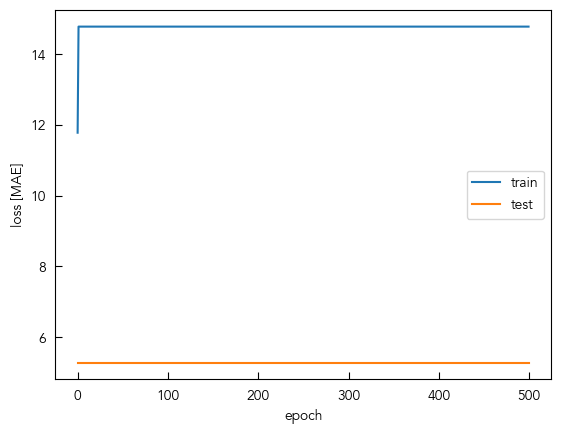

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


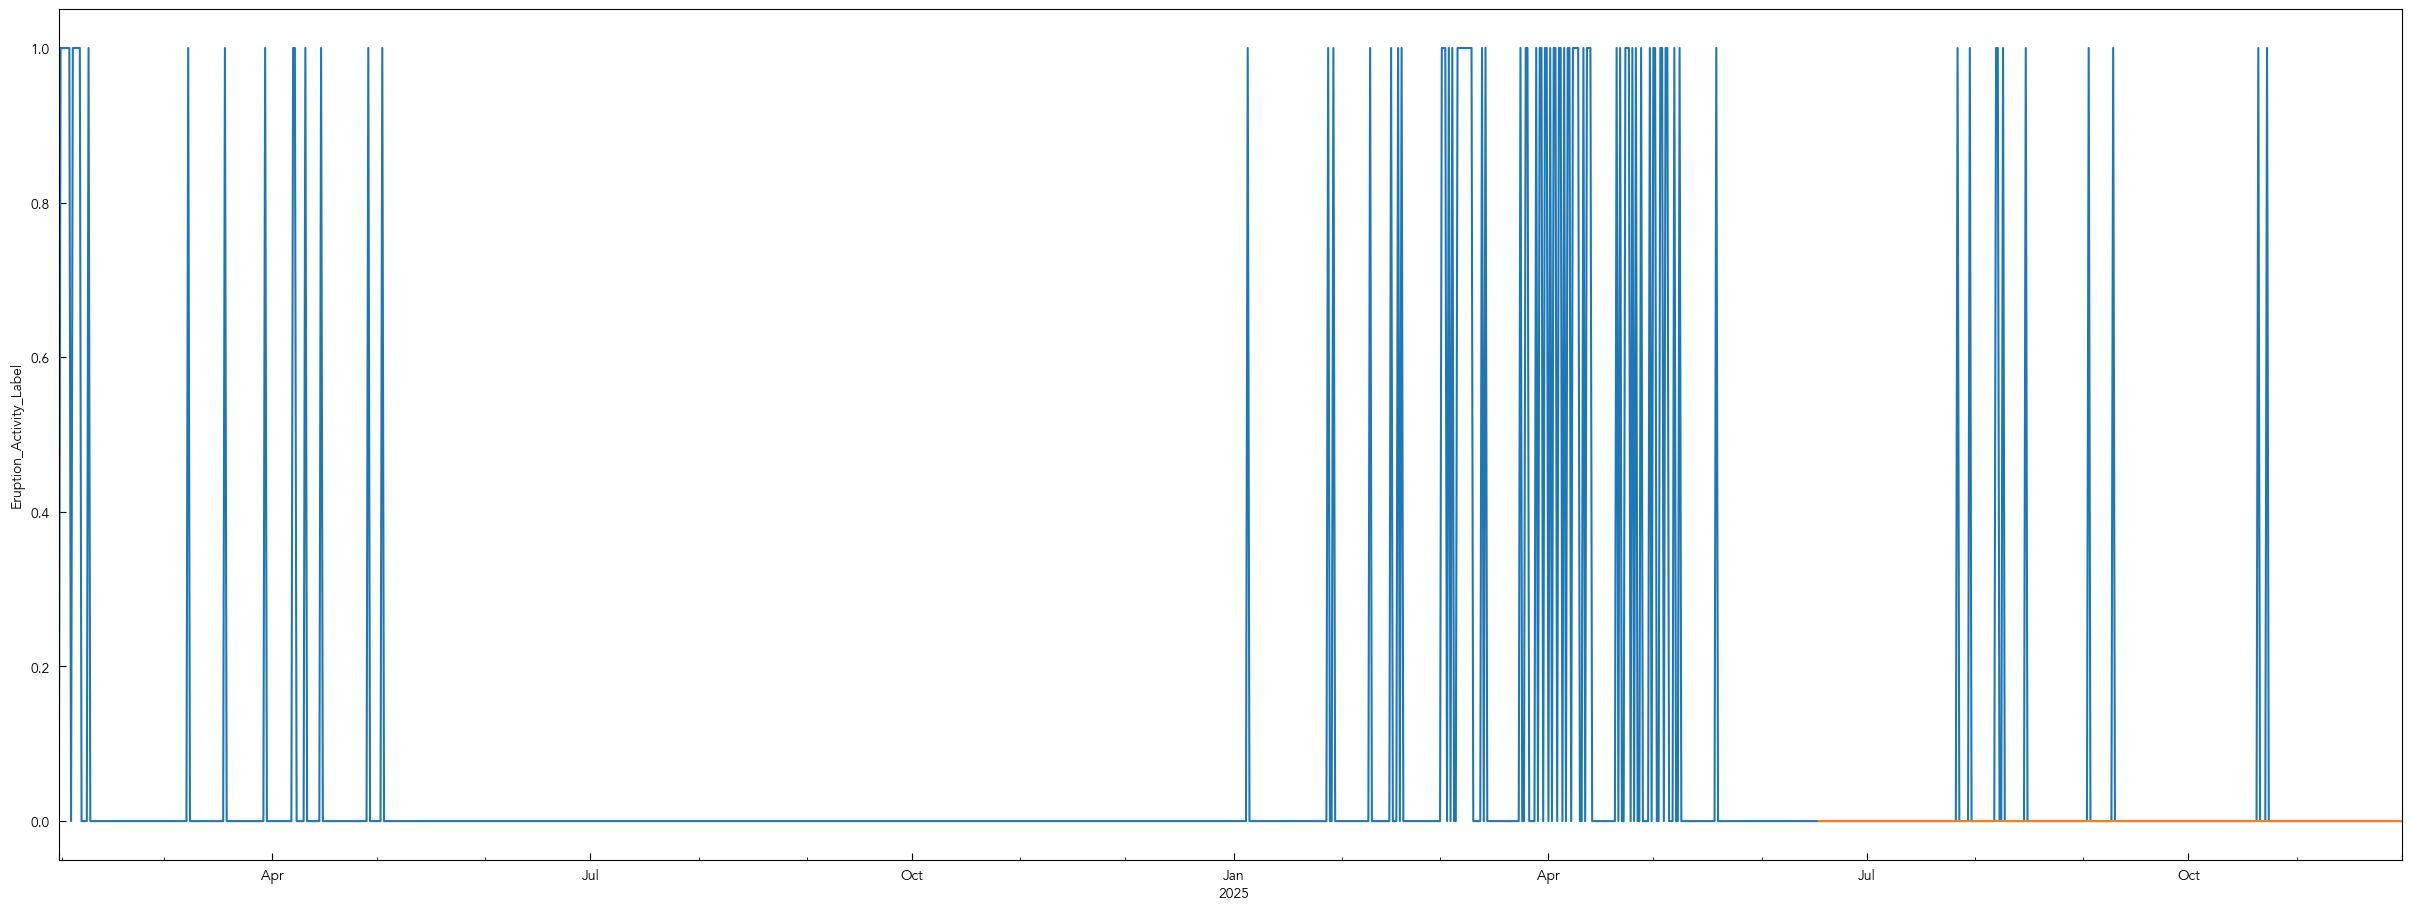

In [4]:
# best params
kwargs = {'n_past':3,
          'n_future':1,
          'n_epochs':500,
          'n_divide':0.75,
          'n_neurons': 128,
          'learning_rate':1e-4,
          'momentum':0.0,
          'opt':'adam',
          'activation':'tanh',
          'task_type':'binary'}


# define model and plot data
lstm = AVERT_LSTM(df, input_vars=input_vars, predict_vars=predict_vars)
lstm.CreateModel(**kwargs)
#lstm.model.summary()
lstm.Fit()
lstm.Predict()
lstm.PlotData([lstm.df_y, lstm.df_yhat], log_vars=[])

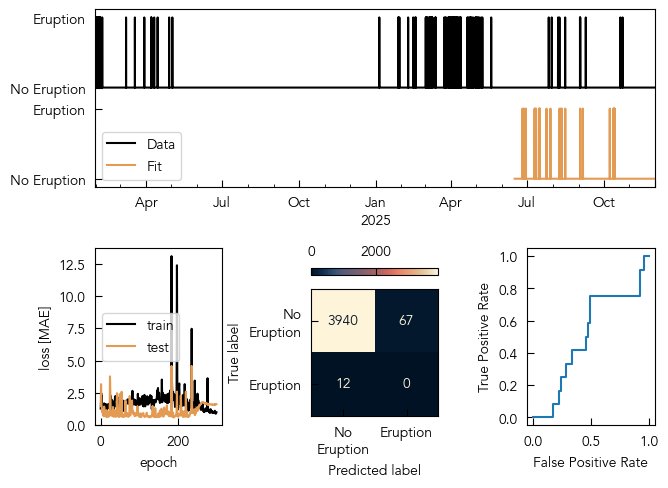

In [90]:
width = 2*86*mm; height = 1.5*86*mm
fig, ax = plt.subplot_mosaic([['A', 'A', 'A'], ['B', 'C', 'D']], figsize=(width, height))

# show forecasting
offset = 1.3
(lstm.df_y + offset).plot(ax=ax['A'], color='black')
lstm.df_yhat.plot(ax=ax['A'], color=palette[9])
ax['A'].set_yticks([0, 1, offset, 1+offset], ['No Eruption', 'Eruption', 'No Eruption', 'Eruption'])
ax['A'].legend(['Data', 'Fit'])
#ax['A'].legend(['Data', 'Fit'], bbox_to_anchor=(0.5, 0.96), loc='lower center', ncol=2,borderpad=0.2)

# plot straining history
history = lstm.model.history
ax['B'].plot(history.history['loss'], label='train', color='black')
ax['B'].plot(history.history['val_loss'], label='test', color=palette[9])
ax['B'].set_xlabel('epoch')
ax['B'].set_ylabel('loss [MAE]')
ax['B'].legend()

# plot confusion matrix
predictions = lstm.df_yhat.values.flatten()
y_test = lstm.df_y.loc[lstm.df_yhat.index].values.flatten()
cm = confusion_matrix(y_test, predictions, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No\nEruption', 'Eruption'])
disp.plot(ax=ax['C'], cmap=cmap, colorbar=False)
plt.colorbar(disp.im_, ax=ax['C'], orientation='horizontal', pad=0.08, location='top', label='')

# plot roc curve
fpr, tpr, _  =  roc_curve(y_test, lstm.df_yhat_prob.values)
ax['D'].plot(fpr, tpr, '-')
ax['D'].set(xlabel='False Positive Rate', ylabel='True Positive Rate')


fig.tight_layout()
#fig.savefig('fig_lstm_classification.pdf', format='pdf', dpi=dpi, transparent=True, bbox_inches='tight', pad_inches=0)